In [60]:
import os, sys, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("Python:", sys.version)
print("Çalışma dizini:", os.getcwd())

csv_files = glob.glob('data/*.csv')  
if not csv_files:
    csv_files = glob.glob('*.csv')    
print("Bulunan CSV dosyaları:", csv_files)


Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
Çalışma dizini: c:\Users\Yusuf\Bitirme Projesi
Bulunan CSV dosyaları: ['ENSO.csv']


In [61]:
csv_path = csv_files[0]  
df = pd.read_csv(csv_path)
print("Önizleme (ilk 5 satır):")
display(df.head())
print("\nSütunlar:", list(df.columns))


Önizleme (ilk 5 satır):


,Unnamed: 0,Date,Year,Month,Global Temperature Anomalies,Global Precipitation,Nino 1+2 SST,Nino 1+2 SST Anomalies,Nino 3 SST,Nino 3 SST Anomalies,...,PNA,OLR,SOI,Season (2-Month),MEI.ext,MEI.v2,Season (3-Month),ONI,Season (12-Month),ENSO Phase-Intensity
0,0,1950-01-01,1950,JAN,-0.19,NaN,NaN,NaN,NaN,NaN,...,-3.65,NaN,NaN,DJ,-0.941,NaN,DJF,-1.5,1950-1951,ML
1,1,1950-02-01,1950,FEB,-0.21,NaN,NaN,NaN,NaN,NaN,...,-1.69,NaN,NaN,JF,-1.131,NaN,JFM,-1.3,1950-1951,ML
2,2,1950-03-01,1950,MAR,-0.06,NaN,NaN,NaN,NaN,NaN,...,-0.06,NaN,NaN,FM,-1.347,NaN,FMA,-1.2,1950-1951,ML
3,3,1950-04-01,1950,APR,-0.17,NaN,NaN,NaN,NaN,NaN,...,-0.23,NaN,NaN,MA,-1.377,NaN,MAM,-1.2,1950-1951,ML
4,4,1950-05-01,1950,MAY,0.01,NaN,NaN,NaN,NaN,NaN,...,-0.40,NaN,NaN,AM,-1.282,NaN,AMJ,-1.1,1950-1951,ML



Sütunlar: ['Unnamed: 0', 'Date', 'Year', 'Month', 'Global Temperature Anomalies', 'Global Precipitation', 'Nino 1+2 SST', 'Nino 1+2 SST Anomalies', 'Nino 3 SST', 'Nino 3 SST Anomalies', 'Nino 3.4 SST', 'Nino 3.4 SST Anomalies', 'Nino 4 SST', 'Nino 4 SST Anomalies', 'TNI OISST', 'TNI HadISST', 'PNA', 'OLR', 'SOI', 'Season (2-Month)', 'MEI.ext', 'MEI.v2', 'Season (3-Month)', 'ONI', 'Season (12-Month)', 'ENSO Phase-Intensity']


In [62]:
print("Info:")
df.info()
print("\nTemel istatistikler:")
display(df.describe(include='all').T)

missing = df.isnull().sum().sort_values(ascending=False)
print("\nEksik değer sayıları (sıfırdan büyük olanlar):")
print(missing[missing>0])


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    900 non-null    int64  
 1   Date                          900 non-null    object 
 2   Year                          900 non-null    int64  
 3   Month                         900 non-null    object 
 4   Global Temperature Anomalies  900 non-null    float64
 5   Global Precipitation          552 non-null    float64
 6   Nino 1+2 SST                  516 non-null    float64
 7   Nino 1+2 SST Anomalies        516 non-null    float64
 8   Nino 3 SST                    516 non-null    float64
 9   Nino 3 SST Anomalies          516 non-null    float64
 10  Nino 3.4 SST                  516 non-null    float64
 11  Nino 3.4 SST Anomalies        516 non-null    float64
 12  Nino 4 SST                    516 non-null    float64
 13 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,900.0,NaN,NaN,NaN,449.5,259.951919,0.0,224.75,449.5,674.25,899.0
Date,900,900,2024-12-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,900.0,NaN,NaN,NaN,1987.0,21.660748,1950.0,1968.0,1987.0,2006.0,2024.0
Month,900,12,JAN,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Global Temperature Anomalies,900.0,NaN,NaN,NaN,0.3563,0.369658,-0.38,0.05,0.3,0.6225,1.44
Global Precipitation,552.0,NaN,NaN,NaN,81.822283,2.853556,71.26,80.2525,82.16,83.8825,88.01
Nino 1+2 SST,516.0,NaN,NaN,NaN,23.25843,2.319866,19.06,21.235,23.17,25.23,28.51
Nino 1+2 SST Anomalies,516.0,NaN,NaN,NaN,-0.019806,1.071426,-1.9,-0.7225,-0.225,0.455,4.03
Nino 3 SST,516.0,NaN,NaN,NaN,25.991415,1.237689,23.38,25.0,25.96,26.975,28.81
Nino 3 SST Anomalies,516.0,NaN,NaN,NaN,-0.033101,0.875181,-2.16,-0.6425,-0.13,0.4625,3.07



Eksik değer sayıları (sıfırdan büyük olanlar):
Nino 3 SST                384
Nino 3 SST Anomalies      384
Nino 1+2 SST Anomalies    384
Nino 1+2 SST              384
Nino 3.4 SST Anomalies    384
Nino 3.4 SST              384
Nino 4 SST Anomalies      384
Nino 4 SST                384
Global Precipitation      348
MEI.v2                    348
OLR                       309
MEI.ext                   228
TNI OISST                  25
SOI                        12
TNI HadISST                 1
dtype: int64


In [63]:

candidates = [c for c in df.columns if any(k in c.lower() for k in ('date','year','time','month'))]
print("Tarih ile ilgili olabilecek sütunlar:", candidates)

if 'Date' in df.columns:
    df['date'] = pd.to_datetime(df['Date'], errors='coerce')
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
elif 'Year' in df.columns and 'Month' in df.columns:
    df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01', errors='coerce')
else:
    if 'Year' in df.columns:
        df['date'] = pd.to_datetime(df['Year'].astype(str), format='%Y', errors='coerce')

if 'date' in df.columns and df['date'].notna().any():
    df = df.set_index('date').sort_index()
    print("Datetime index ayarlandı. İlk 5 indeks:")
    display(df.head())
else:
    print("Otomatik tarih dönüşümü yapılamadı. Lütfen tarih sütununu kontrol et.")


Tarih ile ilgili olabilecek sütunlar: ['Date', 'Year', 'Month', 'Season (2-Month)', 'Season (3-Month)', 'Season (12-Month)']
Datetime index ayarlandı. İlk 5 indeks:


,Unnamed: 0,Date,Year,Month,Global Temperature Anomalies,Global Precipitation,Nino 1+2 SST,Nino 1+2 SST Anomalies,Nino 3 SST,Nino 3 SST Anomalies,...,PNA,OLR,SOI,Season (2-Month),MEI.ext,MEI.v2,Season (3-Month),ONI,Season (12-Month),ENSO Phase-Intensity
date,,,,,,,,,,,,,,,,,,,,,
1950-01-01,0,1950-01-01,1950,JAN,-0.19,NaN,NaN,NaN,NaN,NaN,...,-3.65,NaN,NaN,DJ,-0.941,NaN,DJF,-1.5,1950-1951,ML
1950-02-01,1,1950-02-01,1950,FEB,-0.21,NaN,NaN,NaN,NaN,NaN,...,-1.69,NaN,NaN,JF,-1.131,NaN,JFM,-1.3,1950-1951,ML
1950-03-01,2,1950-03-01,1950,MAR,-0.06,NaN,NaN,NaN,NaN,NaN,...,-0.06,NaN,NaN,FM,-1.347,NaN,FMA,-1.2,1950-1951,ML
1950-04-01,3,1950-04-01,1950,APR,-0.17,NaN,NaN,NaN,NaN,NaN,...,-0.23,NaN,NaN,MA,-1.377,NaN,MAM,-1.2,1950-1951,ML
1950-05-01,4,1950-05-01,1950,MAY,0.01,NaN,NaN,NaN,NaN,NaN,...,-0.40,NaN,NaN,AM,-1.282,NaN,AMJ,-1.1,1950-1951,ML


Sayısal sütunlar: ['Unnamed: 0', 'Year', 'Global Temperature Anomalies', 'Global Precipitation', 'Nino 1+2 SST', 'Nino 1+2 SST Anomalies', 'Nino 3 SST', 'Nino 3 SST Anomalies', 'Nino 3.4 SST', 'Nino 3.4 SST Anomalies', 'Nino 4 SST', 'Nino 4 SST Anomalies', 'TNI OISST', 'TNI HadISST', 'PNA', 'OLR', 'SOI', 'MEI.ext', 'MEI.v2', 'ONI']


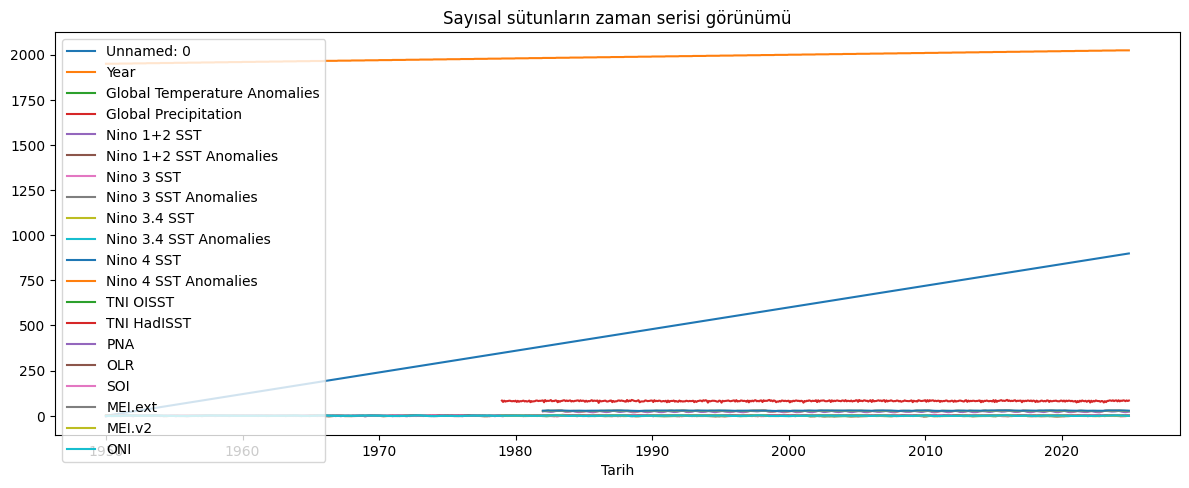

In [64]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Sayısal sütunlar:", num_cols)

if isinstance(df.index, pd.DatetimeIndex) and num_cols:
    plt.figure(figsize=(12,5))
    for c in num_cols:
        plt.plot(df.index, df[c], label=c)
    plt.legend()
    plt.title("Sayısal sütunların zaman serisi görünümü")
    plt.xlabel("Tarih")
    plt.tight_layout()
    plt.show()
else:
    if num_cols:
        df[num_cols[0]].hist(bins=30)
        plt.title(num_cols[0] + " histogram")
        plt.show()


In [65]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Eksik değer yüzdeleri:")
display(missing_pct[missing_pct>0])


Eksik değer yüzdeleri:


Nino 3 SST                42.666667
Nino 3 SST Anomalies      42.666667
Nino 1+2 SST Anomalies    42.666667
Nino 1+2 SST              42.666667
Nino 3.4 SST Anomalies    42.666667
Nino 3.4 SST              42.666667
Nino 4 SST Anomalies      42.666667
Nino 4 SST                42.666667
Global Precipitation      38.666667
MEI.v2                    38.666667
OLR                       34.333333
MEI.ext                   25.333333
TNI OISST                  2.777778
SOI                        1.333333
TNI HadISST                0.111111
dtype: float64

,Unnamed: 0,Year,Global Temperature Anomalies,Global Precipitation,Nino 1+2 SST,Nino 1+2 SST Anomalies,Nino 3 SST,Nino 3 SST Anomalies,Nino 3.4 SST,Nino 3.4 SST Anomalies,Nino 4 SST,Nino 4 SST Anomalies,TNI OISST,TNI HadISST,PNA,OLR,SOI,MEI.ext,MEI.v2,ONI
Unnamed: 0,1.000000,0.999912,0.905206,0.037304,-0.000203,0.035419,0.047067,0.082153,0.061719,0.072461,0.211344,0.220618,-0.273254,-0.212811,0.106497,0.145736,0.009989,0.209604,-0.243273,-0.030597
Year,0.999912,1.000000,0.905525,0.033654,0.016125,0.034925,0.058125,0.082051,0.064672,0.072429,0.206829,0.220676,-0.272731,-0.212240,0.104815,0.146472,0.010473,0.209772,-0.243026,-0.030815
Global Temperature Anomalies,0.905206,0.905525,1.000000,0.071197,0.140651,0.214385,0.219939,0.286622,0.238143,0.275821,0.355679,0.401496,-0.295785,-0.243810,0.183170,0.003294,-0.100673,0.376701,-0.043256,0.137916
Global Precipitation,0.037304,0.033654,0.071197,1.000000,-0.217780,0.085193,-0.115676,0.072660,0.030279,0.074996,0.156471,0.083912,-0.044332,-0.048503,0.067738,-0.088585,-0.017004,0.002854,0.053784,0.074832
Nino 1+2 SST,-0.000203,0.016125,0.140651,-0.217780,1.000000,0.435643,0.784901,0.363229,0.402567,0.288742,-0.020030,0.202350,0.283456,0.314481,-0.048175,-0.170272,-0.174946,0.385853,0.311167,0.296825
Nino 1+2 SST Anomalies,0.035419,0.034925,0.214385,0.085193,0.435643,1.000000,0.550956,0.811925,0.556298,0.640366,0.418806,0.443680,0.429662,0.451312,0.148296,-0.464454,-0.450249,0.746594,0.642865,0.648121
Nino 3 SST,0.047067,0.058125,0.219939,-0.115676,0.784901,0.550956,1.000000,0.691741,0.852387,0.654204,0.444779,0.521838,0.042711,0.077153,0.041683,-0.441908,-0.433095,0.682431,0.577540,0.651708
Nino 3 SST Anomalies,0.082153,0.082051,0.286622,0.072660,0.363229,0.811925,0.691741,1.000000,0.822211,0.940642,0.691157,0.740510,0.019116,0.063284,0.176991,-0.668832,-0.629723,0.889615,0.808584,0.916226
Nino 3.4 SST,0.061719,0.064672,0.238143,0.030279,0.402567,0.556298,0.852387,0.822211,1.000000,0.877384,0.805034,0.783441,-0.248524,-0.209825,0.108145,-0.662454,-0.623966,0.840445,0.750384,0.865939
Nino 3.4 SST Anomalies,0.072461,0.072429,0.275821,0.074996,0.288742,0.640366,0.654204,0.940642,0.877384,1.000000,0.826216,0.884775,-0.262450,-0.213418,0.155648,-0.757011,-0.699390,0.889712,0.847793,0.970820


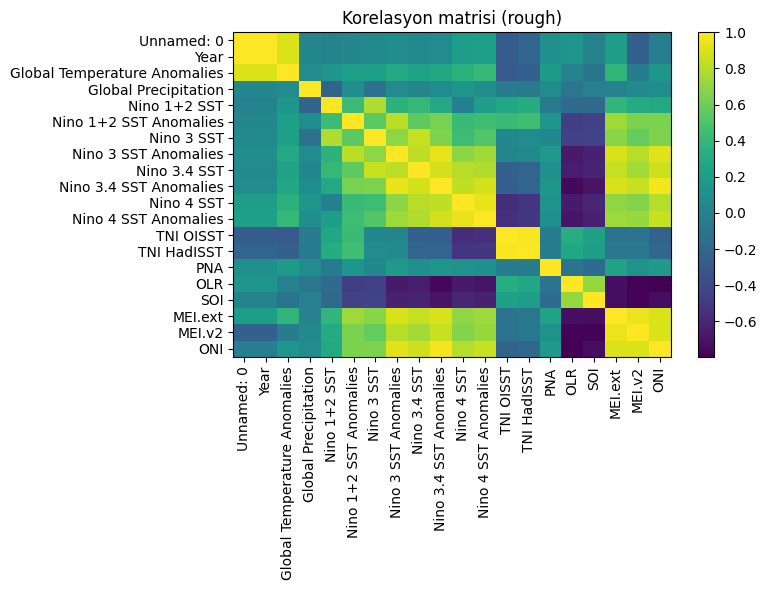

In [66]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    display(corr)
    plt.figure(figsize=(8,6))
    plt.imshow(corr, interpolation='none', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title('Korelasyon matrisi (rough)')
    plt.tight_layout()
    plt.show()
else:
    print("Yeterli sayısal sütun yok; korelasyon atlanıyor.")


Mevcut sütunlar: Index(['Unnamed: 0', 'Year', 'Month', 'Global Temperature Anomalies',
       'Global Precipitation', 'Nino 1+2 SST', 'Nino 1+2 SST Anomalies',
       'Nino 3 SST', 'Nino 3 SST Anomalies', 'Nino 3.4 SST',
       'Nino 3.4 SST Anomalies', 'Nino 4 SST', 'Nino 4 SST Anomalies',
       'TNI OISST', 'TNI HadISST', 'PNA', 'OLR', 'SOI', 'Season (2-Month)',
       'MEI.ext', 'MEI.v2', 'Season (3-Month)', 'ONI', 'Season (12-Month)',
       'ENSO Phase-Intensity'],
      dtype='object')
🔍 Bulunan anomali sayısı: 22
Date
1986-08-01    0.19
1986-09-01    0.40
1986-10-01    0.51
1991-12-01    1.50
1992-01-01    1.67
Name: Nino 3.4 SST Anomalies, dtype: float64


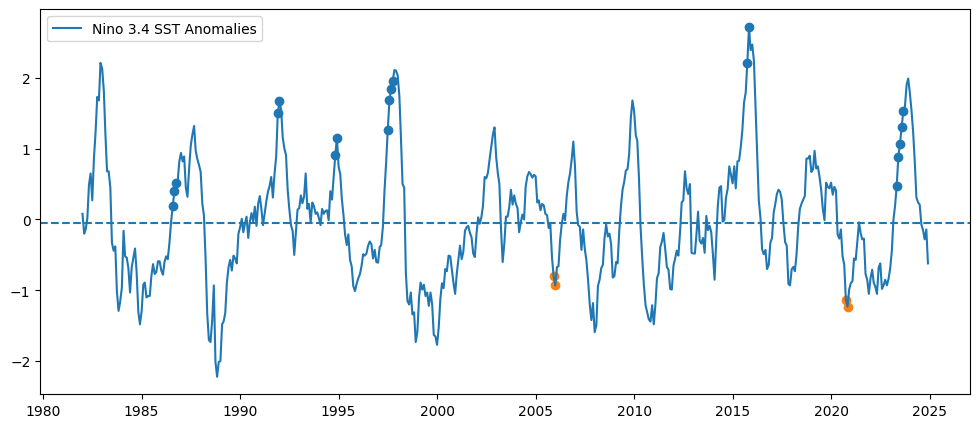

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Eğer Date sütun ise index yap
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.set_index('Date')

print("Mevcut sütunlar:", df.columns)

s = df['Nino 3.4 SST Anomalies'].dropna()

window = 30  
rolling_mean = s.rolling(window=window, min_periods=1).mean()
rolling_std = s.rolling(window=window, min_periods=1).std()

zscore = (s - rolling_mean) / rolling_std.replace(0, np.nan)

anomalies = s[np.abs(zscore) > 2.5]

print("🔍 Bulunan anomali sayısı:", anomalies.shape[0])
print(anomalies.head())

plt.figure(figsize=(12,5))
plt.plot(s.index, s, label='Nino 3.4 SST Anomalies')

plt.scatter(anomalies[anomalies > 0].index, anomalies[anomalies > 0].values)
plt.scatter(anomalies[anomalies < 0].index, anomalies[anomalies < 0].values)

plt.axhline(y=s.mean(), linestyle='--')
plt.legend()
plt.show()

In [68]:
print(df.columns.tolist())

['Unnamed: 0', 'Year', 'Month', 'Global Temperature Anomalies', 'Global Precipitation', 'Nino 1+2 SST', 'Nino 1+2 SST Anomalies', 'Nino 3 SST', 'Nino 3 SST Anomalies', 'Nino 3.4 SST', 'Nino 3.4 SST Anomalies', 'Nino 4 SST', 'Nino 4 SST Anomalies', 'TNI OISST', 'TNI HadISST', 'PNA', 'OLR', 'SOI', 'Season (2-Month)', 'MEI.ext', 'MEI.v2', 'Season (3-Month)', 'ONI', 'Season (12-Month)', 'ENSO Phase-Intensity']


In [73]:
# Eğer varsa sil, yoksa hata verme
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Month metin ise sayıya çevir
df['Month'] = pd.to_datetime(df['Month'], format='%b').dt.month

# Tarih oluştur
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))

# Index yap
df = df.set_index('Date').sort_index()

print("✅ Index tipi:", type(df.index))
print(df.head())

✅ Index tipi: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
            Year  Month  Global Temperature Anomalies  Global Precipitation  \
Date                                                                          
1950-01-01  1950      1                         -0.19                   NaN   
1950-02-01  1950      2                         -0.21                   NaN   
1950-03-01  1950      3                         -0.06                   NaN   
1950-04-01  1950      4                         -0.17                   NaN   
1950-05-01  1950      5                          0.01                   NaN   

            Nino 1+2 SST  Nino 1+2 SST Anomalies  Nino 3 SST  \
Date                                                           
1950-01-01           NaN                     NaN         NaN   
1950-02-01           NaN                     NaN         NaN   
1950-03-01           NaN                     NaN         NaN   
1950-04-01           NaN                     NaN         N

Analiz edilen seri: Nino 3.4 SST Anomalies uzunluk: 516


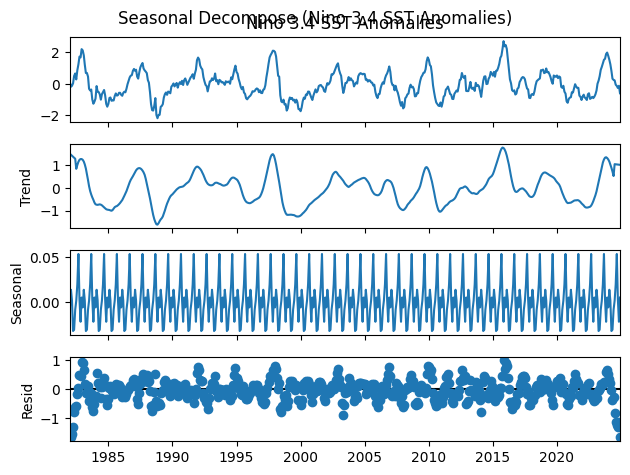

<Figure size 1000x400 with 0 Axes>

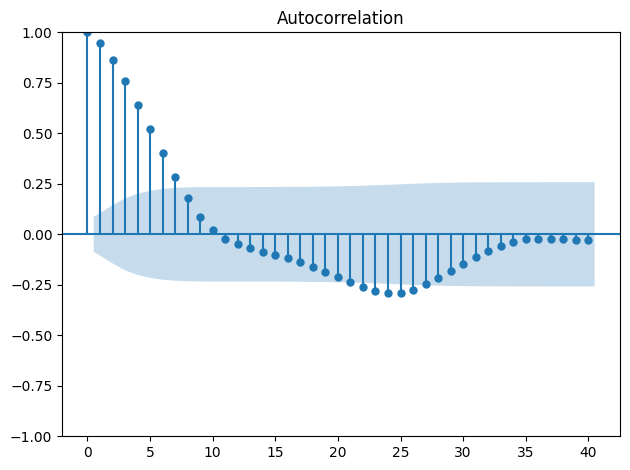

<Figure size 1000x400 with 0 Axes>

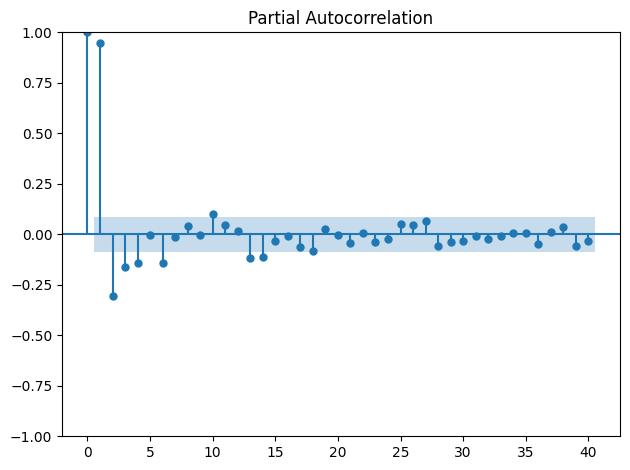

In [74]:
if isinstance(df.index, pd.DatetimeIndex):
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

    series = df['Nino 3.4 SST Anomalies'].dropna()

    print("Analiz edilen seri:", series.name, "uzunluk:", len(series))

    try:
        period = 12  
        res = seasonal_decompose(series, model='additive', period=period, extrapolate_trend='freq')
        res.plot()
        plt.suptitle(f'Seasonal Decompose ({series.name})')
        plt.show()
    except Exception as e:
        print("Decompose hata:", e)

    try:
        plt.figure(figsize=(10,4))
        plot_acf(series, lags=40)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10,4))
        plot_pacf(series, lags=40, method='ywm')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("ACF/PACF hata:", e)
else:
    print("Datetime index eksik; zaman serisi analiz atlanıyor.")


In [75]:
from statsmodels.tsa.stattools import adfuller

series = df['Nino 3.4 SST Anomalies'].dropna()

result = adfuller(series)

print("🔍 ADF Test Sonuçları:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Kritik değerler:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("\n✅ Sonuç: Seri durağandır (p < 0.05). Tahmin modellerine uygundur.")
else:
    print("\n⚠️ Sonuç: Seri durağan değildir (p >= 0.05). Fark alma işlemi gerekebilir.")


🔍 ADF Test Sonuçları:
ADF Statistic: -5.8386
p-value: 0.0000
Kritik değerler:
   1%: -3.4434
   5%: -2.8673
   10%: -2.5698

✅ Sonuç: Seri durağandır (p < 0.05). Tahmin modellerine uygundur.


C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction r

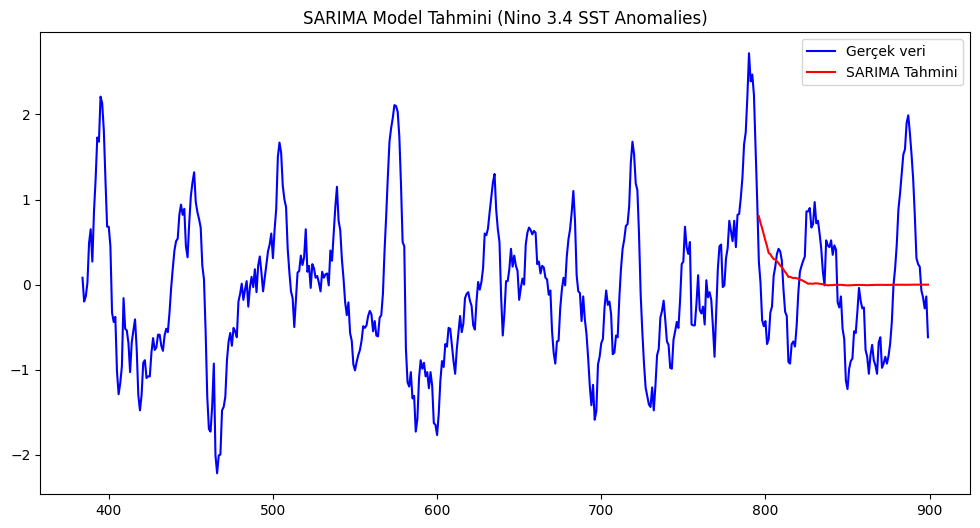

MAE: 0.651, RMSE: 0.778


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

series = df['Nino 3.4 SST Anomalies'].dropna()

train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

model = SARIMAX(train, order=(1,0,1), seasonal_order=(1,0,1,12))
results = model.fit(disp=False)

forecast = results.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(series.index, series, label="Gerçek veri", color="blue")
plt.plot(test.index, forecast, label="SARIMA Tahmini", color="red")
plt.legend()
plt.title("SARIMA Model Tahmini (Nino 3.4 SST Anomalies)")
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}")


C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\CASPER\AppData\Local\Temp\ipykernel_15960\1684581948.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(series.index[-1], periods=13, freq='M')[1:]


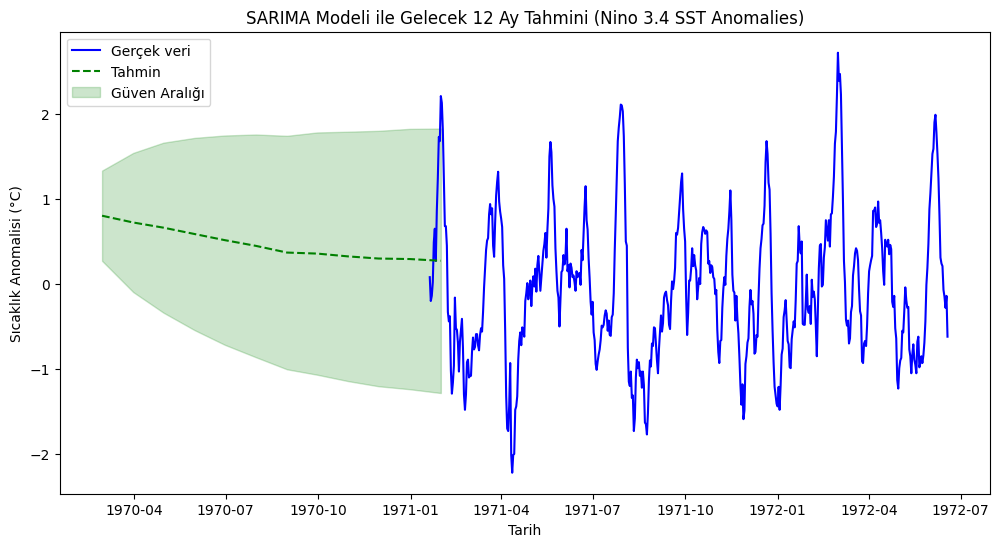

In [ ]:
forecast_obj = results.get_forecast(steps=12)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

future_dates = pd.date_range(series.index[-1], periods=13, freq='M')[1:]

plt.figure(figsize=(12,6))
plt.plot(series.index, series, label="Gerçek veri", color="blue")
plt.plot(future_dates, forecast_mean, label="Tahmin", color="green", linestyle='--')
plt.fill_between(future_dates, conf_int.iloc[:,0], conf_int.iloc[:,1], color='green', alpha=0.2, label="Güven Aralığı")
plt.title("SARIMA Modeli ile Gelecek 12 Ay Tahmini (Nino 3.4 SST Anomalies)")
plt.xlabel("Tarih")
plt.ylabel("Sıcaklık Anomalisi (°C)")
plt.legend()
plt.show()


C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\CASPER\AppData\Local\Temp\ipykernel_15960\189268807.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates_24 = pd.date_range(series.index[-1], periods=25, freq='M')[1:]


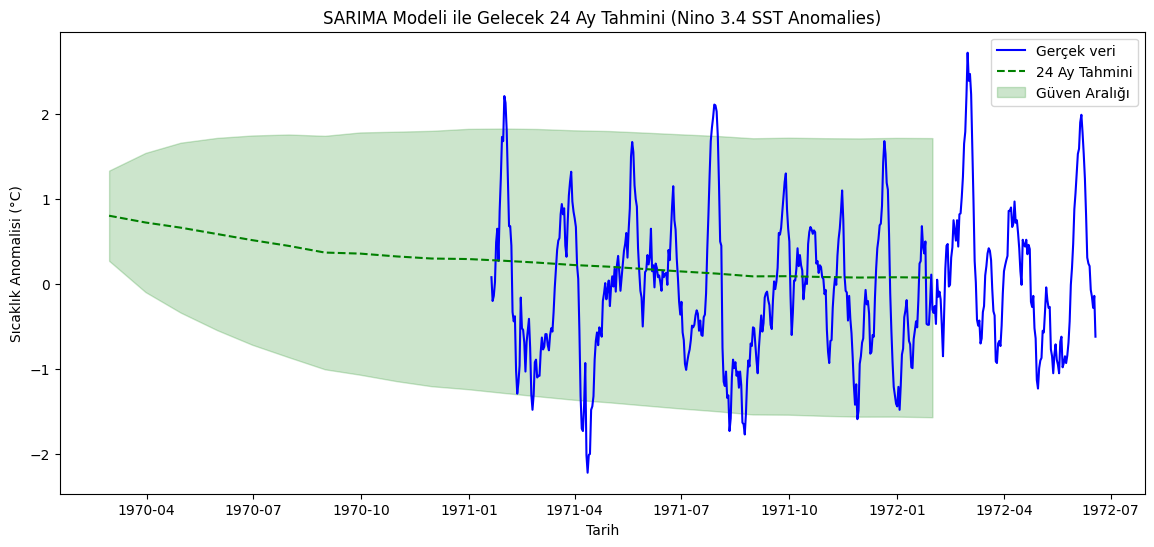

📅 Gelecek 24 Aylık Tahminler:

412    0.802862
413    0.723193
414    0.662475
415    0.587697
416    0.515688
417    0.448337
418    0.369450
419    0.357436
420    0.324109
421    0.299260
422    0.293324
423    0.272760
424    0.251436
425    0.222969
426    0.203467
427    0.175497
428    0.148069
429    0.122261
430    0.089544
431    0.091594
432    0.081666
433    0.075624
434    0.079054
435    0.074200
Name: predicted_mean, dtype: float64


In [ ]:
forecast_obj_24 = results.get_forecast(steps=24)
forecast_mean_24 = forecast_obj_24.predicted_mean
conf_int_24 = forecast_obj_24.conf_int()

future_dates_24 = pd.date_range(series.index[-1], periods=25, freq='M')[1:]

plt.figure(figsize=(14,6))
plt.plot(series.index, series, label="Gerçek veri", color="blue")
plt.plot(future_dates_24, forecast_mean_24, label="24 Ay Tahmini", color="green", linestyle='--')
plt.fill_between(future_dates_24, conf_int_24.iloc[:,0], conf_int_24.iloc[:,1], color='green', alpha=0.2, label="Güven Aralığı")
plt.title("SARIMA Modeli ile Gelecek 24 Ay Tahmini (Nino 3.4 SST Anomalies)")
plt.xlabel("Tarih")
plt.ylabel("Sıcaklık Anomalisi (°C)")
plt.legend()
plt.show()

print("📅 Gelecek 24 Aylık Tahminler:\n")
print(forecast_mean_24)


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

naive_forecast = train.iloc[-1] + np.zeros(len(test))

n = 12
ma_forecast = train.rolling(window=n).mean().iloc[-1] + np.zeros(len(test))

def calc_errors(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    return mae, rmse

sarima_mae, sarima_rmse = calc_errors(test, forecast)

naive_mae, naive_rmse = calc_errors(test, naive_forecast)

ma_mae, ma_rmse = calc_errors(test, ma_forecast)

print("📊 Model Karşılaştırması (Test Dönemi)")
print(f"SARIMA     → MAE: {sarima_mae:.3f}, RMSE: {sarima_rmse:.3f}")
print(f"Naive      → MAE: {naive_mae:.3f}, RMSE: {naive_rmse:.3f}")
print(f"Moving Avg → MAE: {ma_mae:.3f}, RMSE: {ma_rmse:.3f}")


📊 Model Karşılaştırması (Test Dönemi)
SARIMA     → MAE: 0.651, RMSE: 0.778
Naive      → MAE: 1.099, RMSE: 1.246
Moving Avg → MAE: 1.792, RMSE: 1.933


C:\Users\CASPER\AppData\Local\Temp\ipykernel_15960\3384039148.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(series.index[-1], periods=25, freq='M')[1:]


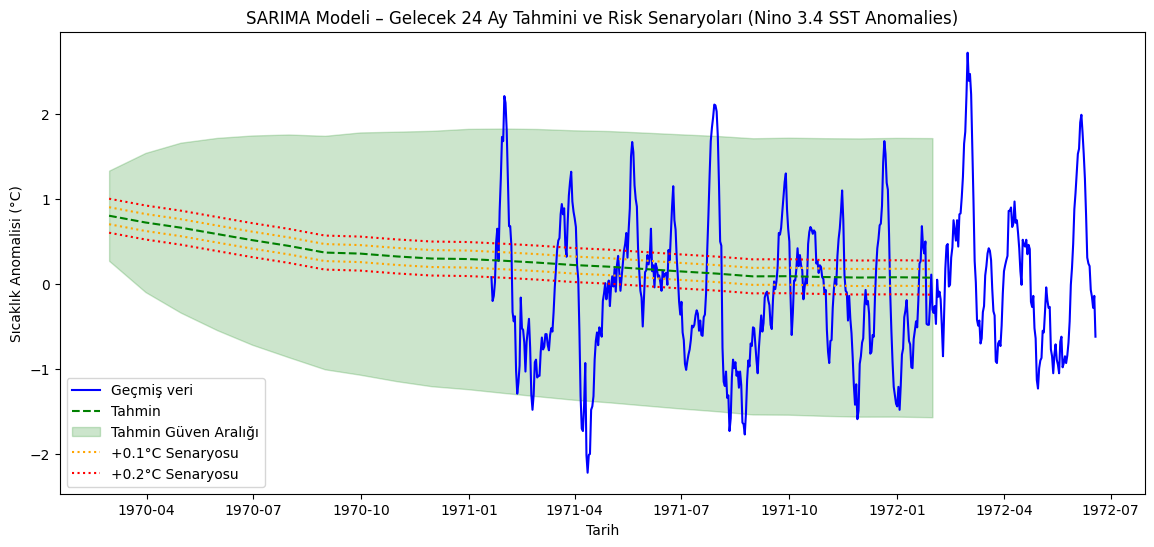

In [ ]:
forecast_mean = forecast_obj_24.predicted_mean
conf_int = forecast_obj_24.conf_int()
future_dates = pd.date_range(series.index[-1], periods=25, freq='M')[1:]

upper_risk_01 = forecast_mean + 0.1
lower_risk_01 = forecast_mean - 0.1

upper_risk_02 = forecast_mean + 0.2
lower_risk_02 = forecast_mean - 0.2

plt.figure(figsize=(14,6))
plt.plot(series.index, series, label="Geçmiş veri", color="blue")
plt.plot(future_dates, forecast_mean, label="Tahmin", color="green", linestyle='--')
plt.fill_between(future_dates, conf_int.iloc[:,0], conf_int.iloc[:,1], color='green', alpha=0.2, label="Tahmin Güven Aralığı")

plt.plot(future_dates, upper_risk_01, color='orange', linestyle=':', label="+0.1°C Senaryosu")
plt.plot(future_dates, lower_risk_01, color='orange', linestyle=':')
plt.plot(future_dates, upper_risk_02, color='red', linestyle=':', label="+0.2°C Senaryosu")
plt.plot(future_dates, lower_risk_02, color='red', linestyle=':')

plt.title("SARIMA Modeli – Gelecek 24 Ay Tahmini ve Risk Senaryoları (Nino 3.4 SST Anomalies)")
plt.xlabel("Tarih")
plt.ylabel("Sıcaklık Anomalisi (°C)")
plt.legend()
plt.show()


📊 ARIMA(1,1,1) Sonuçları:
MAE: 1.413
RMSE: 1.637


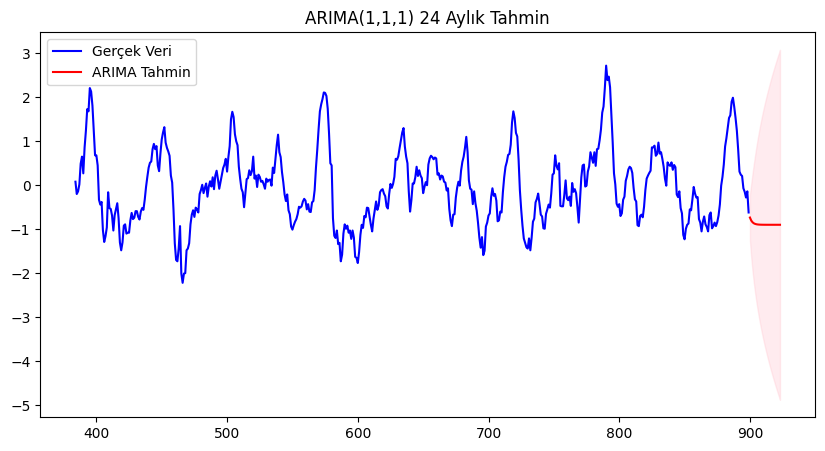

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

model_arima = ARIMA(df['Nino 3.4 SST Anomalies'], order=(1, 1, 1))
results_arima = model_arima.fit()

forecast_arima = results_arima.get_forecast(steps=24)
predicted_mean = forecast_arima.predicted_mean
conf_int = forecast_arima.conf_int()

train_size = len(df) - 24
train, test = df['Nino 3.4 SST Anomalies'][:train_size], df['Nino 3.4 SST Anomalies'][train_size:]
model_arima_eval = ARIMA(train, order=(1, 1, 1)).fit()
forecast_eval = model_arima_eval.forecast(steps=24)

mae = mean_absolute_error(test, forecast_eval)
rmse = np.sqrt(mean_squared_error(test, forecast_eval))

print(f"📊 ARIMA(1,1,1) Sonuçları:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

plt.figure(figsize=(10,5))
plt.plot(df.index, df['Nino 3.4 SST Anomalies'], label="Gerçek Veri", color='blue')
plt.plot(range(len(df), len(df)+24), predicted_mean, label="ARIMA Tahmin", color='red')
plt.fill_between(range(len(df), len(df)+24),
                 conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title("ARIMA(1,1,1) 24 Aylık Tahmin")
plt.show()


📊 ARIMA(2,0,1) Sonuçları:
MAE: 0.198
RMSE: 0.255
                                 SARIMAX Results                                  
Dep. Variable:     Nino 3.4 SST Anomalies   No. Observations:                  516
Model:                     ARIMA(2, 0, 1)   Log Likelihood                 -27.336
Date:                    Sun, 02 Nov 2025   AIC                             64.673
Time:                            12:36:58   BIC                             85.903
Sample:                                 0   HQIC                            72.992
                                    - 516                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0570      0.109     -0.522      0.601      -0.271       0.157
ar.L1          1.7544      0.054     32.690      0

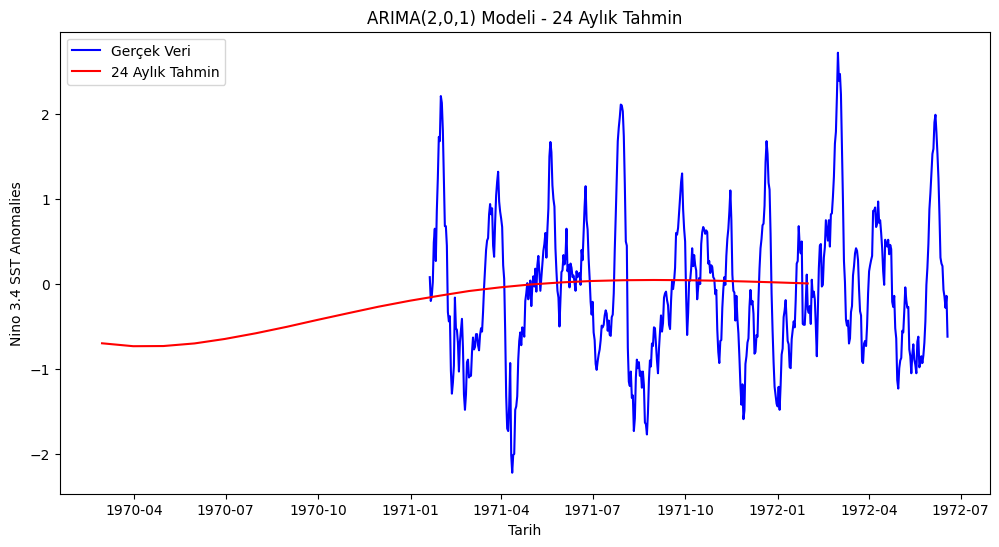

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

series = df['Nino 3.4 SST Anomalies'].dropna()

model_arima = ARIMA(series, order=(2, 0, 1))
model_arima_fit = model_arima.fit()

n_periods = 24
forecast = model_arima_fit.forecast(steps=n_periods)

train_pred = model_arima_fit.predict()
mae = mean_absolute_error(series[-len(train_pred):], train_pred)
rmse = np.sqrt(mean_squared_error(series[-len(train_pred):], train_pred))

print("📊 ARIMA(2,0,1) Sonuçları:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(model_arima_fit.summary())

forecast_index = pd.date_range(start=series.index[-1], periods=n_periods+1, freq='M')[1:]

plt.figure(figsize=(12,6))
plt.plot(series, label='Gerçek Veri', color='blue')
plt.plot(forecast_index, forecast, label='24 Aylık Tahmin', color='red')
plt.title("ARIMA(2,0,1) Modeli - 24 Aylık Tahmin")
plt.xlabel("Tarih")
plt.ylabel("Nino 3.4 SST Anomalies")
plt.legend()
plt.show()


C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\L

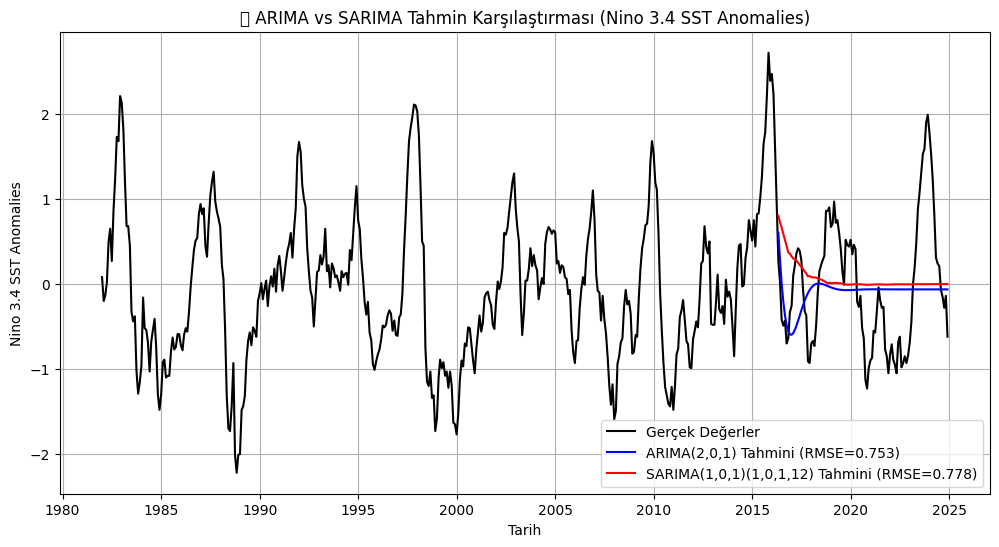

📈 Model Performans Karşılaştırması:
ARIMA(2,0,1) -> MAE: 0.621, RMSE: 0.753
SARIMA(1,0,1)(1,0,1,12) -> MAE: 0.651, RMSE: 0.778


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv("Enso.csv")  
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

series = df['Nino 3.4 SST Anomalies'].dropna()

train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]


arima_model = ARIMA(train, order=(2,0,1))
arima_result = arima_model.fit()
forecast_arima = arima_result.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))


sarima_model = SARIMAX(train, order=(1,0,1), seasonal_order=(1,0,1,12))
sarima_result = sarima_model.fit(disp=False)
forecast_sarima = sarima_result.forecast(steps=len(test))

mae_sarima = mean_absolute_error(test, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))


plt.figure(figsize=(12,6))
plt.plot(series.index, series, label="Gerçek Değerler", color="black")
plt.plot(test.index, forecast_arima, label=f"ARIMA(2,0,1) Tahmini (RMSE={rmse_arima:.3f})", color="blue")
plt.plot(test.index, forecast_sarima, label=f"SARIMA(1,0,1)(1,0,1,12) Tahmini (RMSE={rmse_sarima:.3f})", color="red")

plt.title("📊 ARIMA vs SARIMA Tahmin Karşılaştırması (Nino 3.4 SST Anomalies)")
plt.xlabel("Tarih")
plt.ylabel("Nino 3.4 SST Anomalies")
plt.legend()
plt.grid(True)
plt.show()


print("📈 Model Performans Karşılaştırması:")
print(f"ARIMA(2,0,1) -> MAE: {mae_arima:.3f}, RMSE: {rmse_arima:.3f}")
print(f"SARIMA(1,0,1)(1,0,1,12) -> MAE: {mae_sarima:.3f}, RMSE: {rmse_sarima:.3f}")


In [ ]:
def label_phase(value):
    if value > 0.5:
        return "El Niño"
    elif value < -0.5:
        return "La Niña"
    else:
        return "Normal"

df['Phase'] = df['Nino 3.4 SST Anomalies'].apply(label_phase)
print(df['Phase'].value_counts())
df[['Nino 3.4 SST Anomalies', 'Phase']].head()


Phase
Normal     610
La Niña    170
El Niño    120
Name: count, dtype: int64


,Nino 3.4 SST Anomalies,Phase
Date,,
1950-01-01,NaN,Normal
1950-02-01,NaN,Normal
1950-03-01,NaN,Normal
1950-04-01,NaN,Normal
1950-05-01,NaN,Normal


In [ ]:
features = [
    'Global Temperature Anomalies',
    'Global Precipitation',
    'Nino 1+2 SST Anomalies',
    'Nino 3 SST Anomalies',
    'Nino 4 SST Anomalies',
    'SOI',
    'OLR',
    'MEI.v2'
]

df_model = df.dropna(subset=features + ['Phase'])

X = df_model[features]
y = df_model['Phase']

print("✅ Model verisi hazır:")
print("Satır sayısı:", len(df_model))
print("Sütun sayısı:", len(features))


✅ Model verisi hazır:
Satır sayısı: 510
Sütun sayısı: 8


📊 Sınıflandırma Raporu:
              precision    recall  f1-score   support

     El Niño       0.83      0.83      0.83        23
     La Niña       0.97      0.85      0.91        34
      Normal       0.82      0.89      0.85        45

    accuracy                           0.86       102
   macro avg       0.87      0.86      0.86       102
weighted avg       0.87      0.86      0.86       102



C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


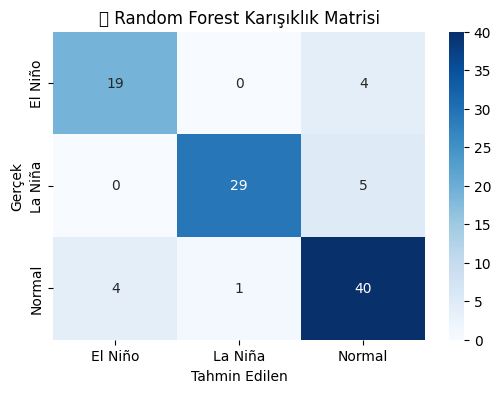

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("📊 Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("🎯 Random Forest Karışıklık Matrisi")
plt.show()


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Özellikler ve hedef
X = df[['Nino 3 SST Anomalies', 'SOI', 'MEI.v2', 'OLR']]  # örnek
y = df['ENSO Phase-Intensity']  # hedef sınıf

# Eğitim ve test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


🔍 Özellik Önem Sıralaması:
                Feature  Importance
1                   SOI    0.325935
2                MEI.v2    0.260384
0  Nino 3 SST Anomalies    0.218819
3                   OLR    0.194862


C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


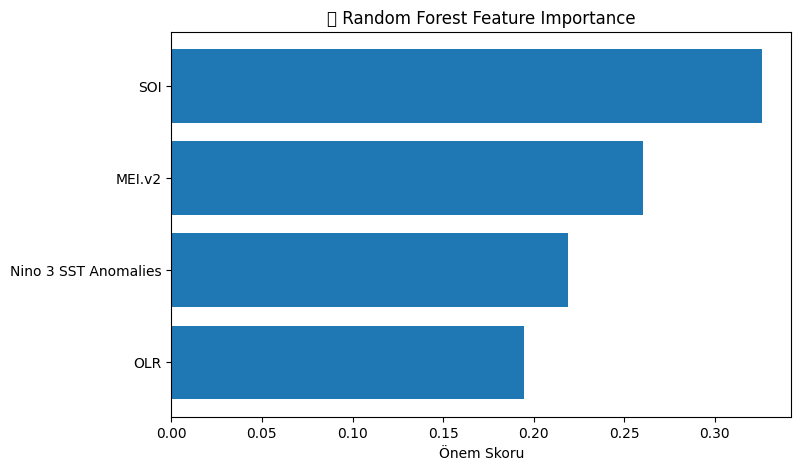

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Özellik önemlerini al
importances = rf_model.feature_importances_

# DataFrame oluştur
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("🔍 Özellik Önem Sıralaması:")
print(feature_importance_df)

# Grafik
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Önem Skoru")
plt.title("🌍 Random Forest Feature Importance")
plt.show()

In [82]:
# Mevcut sütunları ve örnek veriyi göster
print("Sütunlar:", df.columns)
print(df[['ENSO Phase-Intensity']].head(10))

# Boş olmayan değer sayısı
valid_count = df['ENSO Phase-Intensity'].notna().sum()
print("✅ ENSO Phase-Intensity dolu satır sayısı:", valid_count)

# Eğer boşsa önce dolduralım (geçici çözüm)
phase_series = df['ENSO Phase-Intensity'].fillna('Normal')  # veya istediğin default

Sütunlar: Index(['Year', 'Month', 'Global Temperature Anomalies', 'Global Precipitation',
       'Nino 1+2 SST', 'Nino 1+2 SST Anomalies', 'Nino 3 SST',
       'Nino 3 SST Anomalies', 'Nino 3.4 SST', 'Nino 3.4 SST Anomalies',
       'Nino 4 SST', 'Nino 4 SST Anomalies', 'TNI OISST', 'TNI HadISST', 'PNA',
       'OLR', 'SOI', 'Season (2-Month)', 'MEI.ext', 'MEI.v2',
       'Season (3-Month)', 'ONI', 'Season (12-Month)', 'ENSO Phase-Intensity'],
      dtype='object')
           ENSO Phase-Intensity
Date                           
1950-01-01                   ML
1950-02-01                   ML
1950-03-01                   ML
1950-04-01                   ML
1950-05-01                   ML
1950-06-01                   ML
1950-07-01                   ML
1950-08-01                   ML
1950-09-01                   ML
1950-10-01                   ML
✅ ENSO Phase-Intensity dolu satır sayısı: 900


C:\Users\CASPER\AppData\Local\Temp\ipykernel_1172\2141450225.py:46: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


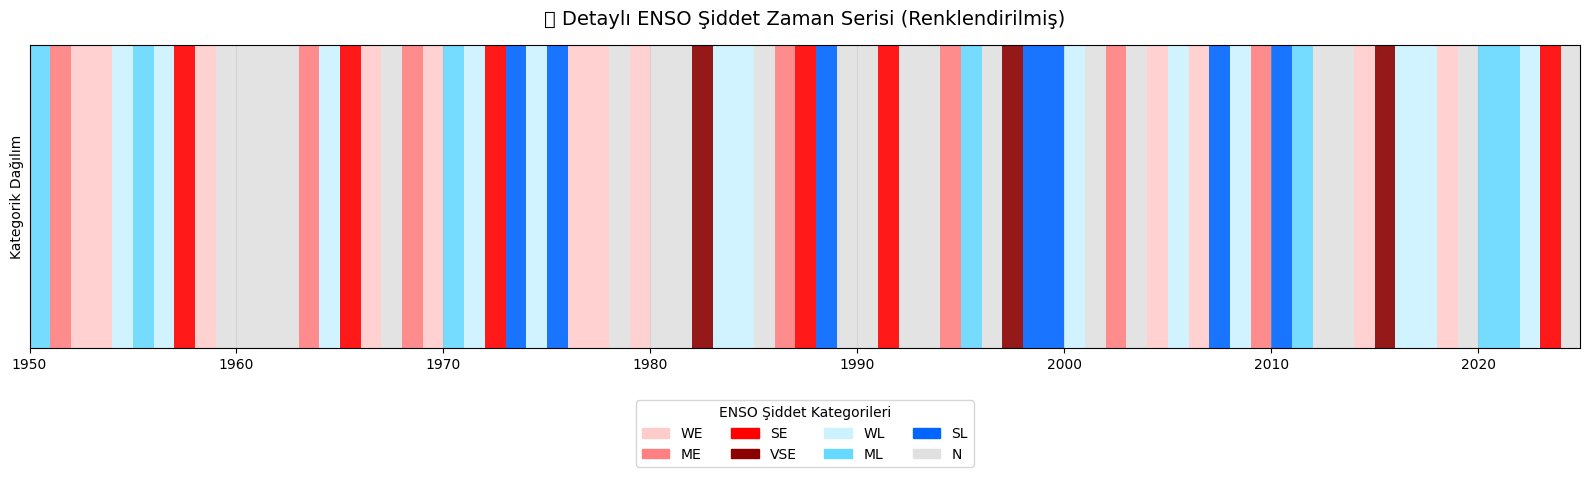

In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

# Renk Paleti (Sözlük Yapısı)
enso_colors = {
    # El Niño Tonları (Sıcağa doğru)
    'WE':  '#ffcccc', # Weak - Açık Pembe
    'ME':  '#ff8080', # Moderate - Açık Kırmızı
    'SE':  '#ff0000', # Strong - Kırmızı
    'VSE': '#8b0000', # Very Strong - Koyu Bordo
    
    # La Niña Tonları (Soğuğa doğru)
    'WL':  '#ccf2ff', # Weak - Açık Turkuaz
    'ML':  '#66d9ff', # Moderate - Gök Mavisi
    'SL':  '#0066ff', # Strong - Koyu Mavi
    
    # Nötr
    'N':   '#e0e0e0'  # Neutral - Açık Gri
}

plt.figure(figsize=(16, 5))

for idx in range(len(df)):
    start = df.index[idx]
    # Bir sonraki aya kadar uzat (boşluk kalmaması için)
    end = start + pd.DateOffset(months=1)
    
    # Hücredeki değeri al ve sözlükten rengi çek
    phase = str(df['ENSO Phase-Intensity'].iloc[idx]).strip()
    color = enso_colors.get(phase, '#ffffff') # Listede yoksa beyaz yap
    
    plt.axvspan(start, end, color=color, alpha=0.9, linewidth=0)

# --- Lejant (Legend) Ayarları ---
# El Niño ve La Niña için iki ayrı grup lejant oluşturabiliriz
patches = [mpatches.Patch(color=v, label=k) for k, v in enso_colors.items()]
plt.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=4, title="ENSO Şiddet Kategorileri")

plt.title("🌊 Detaylı ENSO Şiddet Zaman Serisi (Renklendirilmiş)", fontsize=14, pad=15)
plt.ylabel("Kategorik Dağılım")
plt.yticks([]) # Y ekseni değerine gerek yok
plt.xlim(df.index.min(), df.index.max())
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()